In [1]:
import psutil
ram = psutil.virtual_memory()
print(f"Total RAM: {round(ram.total/1024**3, 2)} GB")
print(f"Available RAM: {round(ram.available/1024**3, 2)} GB")

Total RAM: 12.67 GB
Available RAM: 11.78 GB


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
movies = pd.read_csv("TMDB_movie_dataset_v11.csv", on_bad_lines='skip', engine='python')

In [4]:
movies.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [5]:
movies.shape

(1394685, 24)

In [6]:
movies.columns

Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords'],
      dtype='object')

In [7]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1394685 entries, 0 to 1394684
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1394685 non-null  int64  
 1   title                 1394667 non-null  object 
 2   vote_average          1394685 non-null  float64
 3   vote_count            1394685 non-null  int64  
 4   status                1394685 non-null  object 
 5   release_date          1091702 non-null  object 
 6   revenue               1394685 non-null  int64  
 7   runtime               1394685 non-null  int64  
 8   adult                 1394685 non-null  bool   
 9   backdrop_path         348351 non-null   object 
 10  budget                1394685 non-null  int64  
 11  homepage              143774 non-null   object 
 12  imdb_id               663024 non-null   object 
 13  original_language     1394685 non-null  object 
 14  original_title        1394667 non-

In [8]:
cols_to_drop = ['adult', 'backdrop_path', 'poster_path', 'homepage',
                'imdb_id', 'budget', 'revenue', 'runtime', 'tagline',
                'production_companies', 'production_countries',
                'spoken_languages', 'status', 'original_title']

movies = movies.drop(columns=cols_to_drop)
print(movies.columns)
print(movies.shape)

Index(['id', 'title', 'vote_average', 'vote_count', 'release_date',
       'original_language', 'overview', 'popularity', 'genres', 'keywords'],
      dtype='object')
(1394685, 10)


In [9]:
movies.isnull().sum()

,0
id,0
title,18
vote_average,0
vote_count,0
release_date,302983
original_language,0
overview,318175
popularity,0
genres,608352
keywords,1047602


In [10]:
# Step 1 — Drop rows where overview is null
movies = movies.dropna(subset=['overview'])

# Step 2 — Fill remaining nulls
movies['vote_average'] = movies['vote_average'].fillna(movies['vote_average'].mean())
movies['original_language'] = movies['original_language'].fillna('en')
movies['popularity'] = movies['popularity'].fillna(movies['popularity'].median())
movies['keywords'] = movies['keywords'].fillna('')
movies['genres'] = movies['genres'].fillna('')

# Step 3 — Reset index
movies = movies.reset_index(drop=True)

# Step 4 — Check nulls again
print(movies.isnull().sum())
print(f"\nFinal shape: {movies.shape}")

id                        0
title                     6
vote_average              0
vote_count                0
release_date         181804
original_language         0
overview                  0
popularity                0
genres                    0
keywords                  0
dtype: int64

Final shape: (1076510, 10)


In [11]:
movies = movies.drop(columns=['release_date'])
print(movies.columns)

Index(['id', 'title', 'vote_average', 'vote_count', 'original_language',
       'overview', 'popularity', 'genres', 'keywords'],
      dtype='object')


In [12]:
movies.isnull().sum()

,0
id,0
title,6
vote_average,0
vote_count,0
original_language,0
overview,0
popularity,0
genres,0
keywords,0


In [13]:
movies = movies.dropna(subset=['title'])
print(f"Final shape: {movies.shape}")
print(movies.isnull().sum())

Final shape: (1076504, 9)
id                   0
title                0
vote_average         0
vote_count           0
original_language    0
overview             0
popularity           0
genres               0
keywords             0
dtype: int64


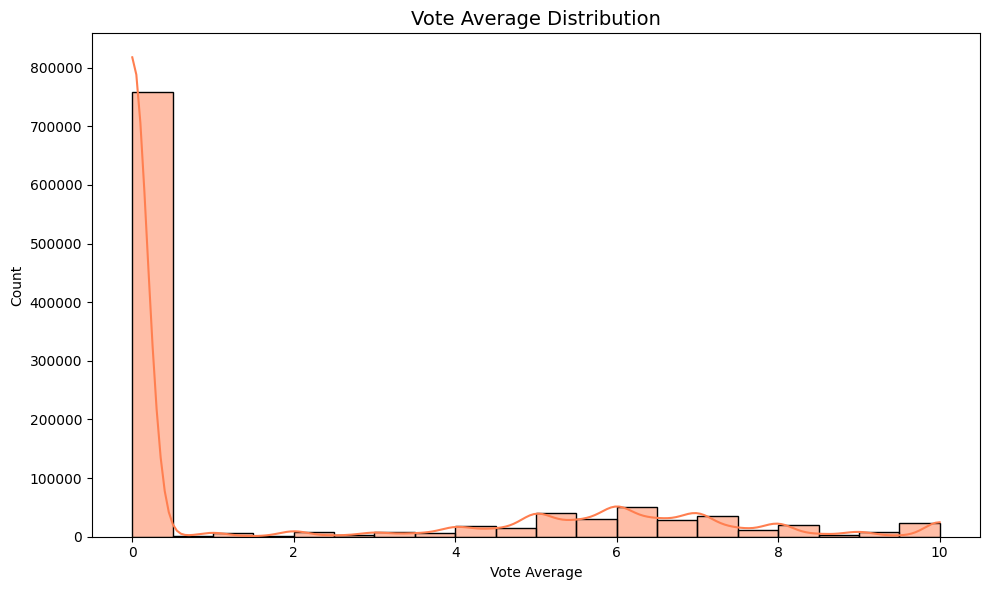

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(movies['vote_average'], bins=20, kde=True, color='coral', ax=ax)
ax.set_title('Vote Average Distribution', fontsize=14)
ax.set_xlabel('Vote Average')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

/tmp/ipykernel_5341/2612237868.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='magma', ax=ax)


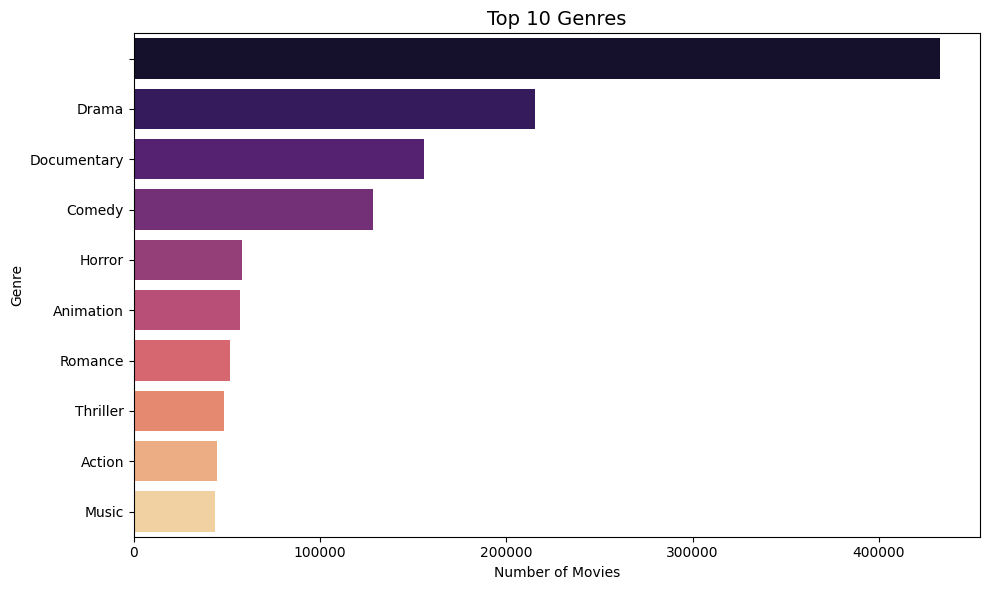

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
genre_list = movies['genres'].str.split(',').explode().str.strip()
genre_counts = genre_list.value_counts().head(10)
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='magma', ax=ax)
ax.set_title('Top 10 Genres', fontsize=14)
ax.set_xlabel('Number of Movies')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.show()

In [16]:
movies.columns

Index(['id', 'title', 'vote_average', 'vote_count', 'original_language',
       'overview', 'popularity', 'genres', 'keywords'],
      dtype='object')

In [17]:
# Give more weight to genres by repeating it
movies['tags'] = (
    movies['genres'] + ' ' +
    movies['genres'] + ' ' +  # repeat 2x
    movies['genres'] + ' ' +  # repeat 3x
    movies['keywords'] + ' ' +
    movies['original_language'] + ' ' +
    movies['overview']
)

movies['tags'] = movies['tags'].str.lower()

In [18]:
movies.head()

,id,title,vote_average,vote_count,original_language,overview,popularity,genres,keywords,tags
0,27205,Inception,8.364,34495,en,"Cobb, a skilled thief who commits corporate es...",83.952,"Action, Science Fiction, Adventure","rescue, mission, dream, airplane, paris, franc...","action, science fiction, adventure action, sci..."
1,157336,Interstellar,8.417,32571,en,The adventures of a group of explorers who mak...,140.241,"Adventure, Drama, Science Fiction","rescue, future, spacecraft, race against time,...","adventure, drama, science fiction adventure, d..."
2,155,The Dark Knight,8.512,30619,en,Batman raises the stakes in his war on crime. ...,130.643,"Drama, Action, Crime, Thriller","joker, sadism, chaos, secret identity, crime f...","drama, action, crime, thriller drama, action, ..."
3,19995,Avatar,7.573,29815,en,"In the 22nd century, a paraplegic Marine is di...",79.932,"Action, Adventure, Fantasy, Science Fiction","future, society, culture clash, space travel, ...","action, adventure, fantasy, science fiction ac..."
4,24428,The Avengers,7.710,29166,en,When an unexpected enemy emerges and threatens...,98.082,"Science Fiction, Action, Adventure","new york city, superhero, shield, based on com...","science fiction, action, adventure science fic..."


In [19]:
movies.shape

(1076504, 10)

In [20]:
new_df = movies[['id', 'title', 'genres', 'overview', 'tags']]
print(new_df.shape)

(1076504, 5)


In [21]:
new_df=new_df.drop(columns=['overview'])
new_df.head()

,id,title,genres,tags
0,27205,Inception,"Action, Science Fiction, Adventure","action, science fiction, adventure action, sci..."
1,157336,Interstellar,"Adventure, Drama, Science Fiction","adventure, drama, science fiction adventure, d..."
2,155,The Dark Knight,"Drama, Action, Crime, Thriller","drama, action, crime, thriller drama, action, ..."
3,19995,Avatar,"Action, Adventure, Fantasy, Science Fiction","action, adventure, fantasy, science fiction ac..."
4,24428,The Avengers,"Science Fiction, Action, Adventure","science fiction, action, adventure science fic..."


In [36]:
new_df_limit=new_df.head(500000)
new_df_limit.shape

(500000, 4)

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))

# ✅ NO .toarray() — keep sparse matrix!
vec = tfidf.fit_transform(new_df_limit['tags'])
print(vec.shape)

(500000, 5000)


In [38]:
from sklearn.metrics.pairwise import cosine_similarity

In [39]:
index = new_df[new_df['title'] == 'The Dark Knight'].index[0]
print(index)

2


In [41]:
sim_scores = cosine_similarity(vec[index], vec).flatten()
print(sim_scores.shape)

(500000,)


In [42]:
distance = sorted(list(enumerate(sim_scores)), reverse=True, key=lambda x: x[1])
print(distance[:5])

[(2, np.float64(0.9999999999999999)), (447684, np.float64(0.554790795959231)), (31900, np.float64(0.5534815200011883)), (224828, np.float64(0.5512777069804967)), (312499, np.float64(0.5311218008054016))]


In [43]:
print("Top 5 movies similar to 'The Dark Knight':")
for i in distance[1:6]:
    print(new_df_limit.iloc[i[0]].title)

Top 5 movies similar to 'The Dark Knight':
Street Wars
Malik
Wrath of Briand
The Life Before This
Open City


In [44]:
def recommend(movie):
    matches = new_df_limit[new_df_limit['title'] == movie]
    if matches.empty:
        print(f"Movie '{movie}' not found!")
        return

    index = matches.index[0]
    sim_scores = cosine_similarity(vec[index], vec).flatten()
    distance = sorted(list(enumerate(sim_scores)), reverse=True, key=lambda x: x[1])

    print(f"\nTop 5 movies similar to '{movie}':")
    for i in distance[1:6]:
        print(new_df_limit.iloc[i[0]].title)

In [45]:
recommend('The Dark Knight')


Top 5 movies similar to 'The Dark Knight':
Street Wars
Malik
Wrath of Briand
The Life Before This
Open City


In [46]:
recommend('Dilwale Dulhania Le Jayenge')


Top 5 movies similar to 'Dilwale Dulhania Le Jayenge':
Qaqanın Gündəliyi 3: Razablaçonnu Məhəbbət
Under the Bridges
Dedh Ishqiya
Salaam-e-Ishq
Sabah


In [47]:
def model_accuracy(test_cases, k=5):
    scores = []

    for movie, genre in test_cases:
        matches = new_df[new_df['title'] == movie]
        if matches.empty:
            continue

        index = matches.index[0]
        sim_scores = cosine_similarity(vec[index], vec).flatten()
        top_k = sim_scores.argsort()[::-1][1:k+1]

        relevant = sum(1 for i in top_k
                      if genre.lower() in str(new_df.iloc[i]['genres']).lower())

        scores.append(relevant / k)

    accuracy = round(sum(scores) / len(scores) * 100, 2)
    print(f"Model Accuracy: {accuracy}%")
    return accuracy

In [48]:
test_cases = [('The Dark Knight', 'Action'),
    ('The Godfather', 'Crime'),
    ('Iron Man', 'Action'),
    ('Titanic', 'Romance'),
    ('Spirited Away', 'Animation')]


model_accuracy(test_cases)

Model Accuracy: 88.0%


88.0